In [1]:
complexity_idx = int(input("INPUT 'visualization_target for complexity RUN_ID'(e.g., 20000): "))

print(f'Figure will be drawn based on the run_id_{complexity_idx} dataset')

Figure will be drawn based on the run_id_20000 dataset


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_jsonl

import lib.stats.chowtest as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.code_complexity.tools.Result_Prep import Result_Prep as Result_Prep_C
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.figure_setting as figure_setting
from lib.visualization.plot_generator import PlotGen
mpl.rcParams.update(figure_setting.fig_setting)
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

import statsmodels.formula.api as smf
from scipy import stats

from scipy.stats import linregress, ttest_1samp
from statsmodels.stats.multitest import multipletests

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D







In [3]:
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
MIN_WEEK     = -104
MAX_WEEK     = +160
MIN_PRE  = 50
MIN_POST = 50

In [4]:
tot_viz_df = pd.DataFrame()
for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
    print(f'[visualizing....] start visualizing {lang} language')
    rp_c = Result_Prep_C(int(complexity_idx)+idx)
    viz_df = rp_c.data_prep_for_all(lang)
    tot_viz_df = pd.concat([tot_viz_df, viz_df], ignore_index=True)


weekly = rp_c.data_prep_for_its(tot_viz_df)
weekly.head()

[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:13<00:00,  4.74it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:07<00:00,  9.11it/s]


[visualizing....] start visualizing java language


...

[visualizing....] start visualizing fortran language


100%|██████████| 65/65 [00:00<00:00, 1243.91it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 802.15it/s]


,language,rel_week,log_cc_mean,n_func
0,c,-104,1.246516,741
1,c,-103,1.257209,741
2,c,-102,1.237901,595
3,c,-101,1.309187,538
4,c,-100,1.218416,569


In [5]:
panel = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] Aggreagate data for {lang} language')
    tmp = load_df(f'/mnt/hdd/mghan/so_data_availability/result/tag/run_id_{100+idx}/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp['language'] = lang
    panel = pd.concat([panel, tmp], axis = 0)

[Start....] Aggreagate data for python language


100%|██████████| 153/153 [00:06<00:00, 23.81it/s]


[Start....] Aggreagate data for javascript language


100%|██████████| 108/108 [00:04<00:00, 23.03it/s]


[Start....] Aggreagate data for java language


...

100%|██████████| 1/1 [00:00<00:00, 76.40it/s]


[Start....] Aggreagate data for f# language


100%|██████████| 1/1 [00:00<00:00, 122.16it/s]


[Start....] Aggreagate data for solidity language


100%|██████████| 2/2 [00:00<00:00, 60.70it/s]


In [6]:
panel['rel_week'] = (pd.to_datetime(panel['cdate']) - datetime(2022, 11, 30)).dt.days //7
panel = panel[panel['rel_week']<0].groupby(['language'])['pct'].sum().reset_index().rename(columns = {'pct' : 'post_count'})
panel['log_post_count'] = np.log(panel['post_count'])

In [8]:
lang_df = weekly.copy()

In [9]:
lang_df

,language,rel_week,log_cc_mean,n_func
0,c,-104,1.246516,741
1,c,-103,1.257209,741
2,c,-102,1.237901,595
3,c,-101,1.309187,538
4,c,-100,1.218416,569
...,...,...,...,...
4650,typescript,139,0.852078,40
4652,typescript,141,0.859478,35
4656,typescript,145,1.062935,50
4657,typescript,146,0.769529,50


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import re

TARGET = 'log_cc_mean'   # 필요시 'log_y'(질문량)로 교체

# ============================================================
# 0. 데이터 준비
# ============================================================
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]
# lang_df["log_y"] = np.log(lang_df["n_docs"] + 1)

# ============================================================
# 1. Overall Saturated 모델 (하나로 전체 + 언어별 slope 다 뽑기)
# ============================================================
formula = (f"{TARGET} ~ t + post + post_t "
           "+ C(language) + C(language):t "
           "+ C(language):post + C(language):post_t")
print(formula)

m = smf.ols(formula, data=lang_df).fit(
    cov_type="cluster", cov_kwds={"groups": lang_df["language"]}
)

overall_p = m.pvalues['post_t']

# ============================================================
# 2. 언어별 slope 추출 (delta method)
# ============================================================
pat_post_t = re.compile(r"C\(language\)\[T\.(.+?)\]:post_t$")
interaction_names = {pat_post_t.match(n).group(1): n
                     for n in m.params.index if pat_post_t.match(n)}

all_langs = list(lang_df["language"].unique())
baseline_lang = [l for l in all_langs if l not in interaction_names][0]

cov = m.cov_params()
rows = []
rows.append({"language": baseline_lang, "slope": m.params["post_t"], "se": m.bse["post_t"]})

for lang, pname in interaction_names.items():
    beta, delta = m.params["post_t"], m.params[pname]
    slope = beta + delta
    v_beta, v_delta = cov.loc["post_t","post_t"], cov.loc[pname,pname]
    cov_bd = cov.loc["post_t", pname]
    var_slope = v_beta + v_delta + 2*cov_bd
    se_slope = np.sqrt(max(var_slope, 0))
    rows.append({"language": lang, "slope": slope, "se": se_slope})

slope_df = pd.DataFrame(rows)

# ============================================================
# 3. log-scale -> 연간(%) 변환 (Image 1처럼 % per year)
# ============================================================
WEEKS_PER_YEAR = 52
slope_df['slope_yr'] = slope_df['slope'] * WEEKS_PER_YEAR
slope_df['se_yr']    = slope_df['se']    * WEEKS_PER_YEAR

slope_df['pct']     = (np.exp(slope_df['slope_yr']) - 1) * 100
slope_df['ci_low']  = (np.exp(slope_df['slope_yr'] - 1.96*slope_df['se_yr']) - 1) * 100
slope_df['ci_high'] = (np.exp(slope_df['slope_yr'] + 1.96*slope_df['se_yr']) - 1) * 100

slope_df['p_value'] = 2 * (1 - stats.norm.cdf(np.abs(slope_df['slope_yr'] / slope_df['se_yr'])))
slope_df['significant'] = slope_df['p_value'] < 0.05

def get_color(row):
    if not row['significant']:
        return '#999999'
    elif row['pct'] > 0:
        return figure_setting.PALETTE['accent']
    else:
        return figure_setting.PALETTE['primary']

slope_df['color_slope'] = slope_df.apply(get_color, axis=1)
slope_df['alpha'] = 1.0

# ============================================================
# 4. x축용: pre-GPT 누적 질문량 (log10)
# ============================================================
# pre_data = (lang_df[lang_df['post']==0]
#             .groupby('language')['n_docs'].sum()
#             .reset_index().rename(columns={'n_docs':'pre_n_docs'}))
# pre_data['log_post_count'] = np.log10(pre_data['pre_n_docs'] + 1)
# slope_df = pd.merge(slope_df, pre_data, on='language')


pre_data = panel.copy()
slope_df = pd.merge(slope_df, pre_data, on='language')

# ============================================================
# 5. OLS 피팅 (오른쪽 산점도용)
# ============================================================
x = slope_df['log_post_count'].values
y = slope_df['pct'].values

slope_fit, intercept_fit, r_val, p_val, se_fit = stats.linregress(x, y)
r_squared = r_val ** 2

xx = np.linspace(x.min(), x.max(), 100)
yy = slope_fit * xx + intercept_fit

n = len(x)
x_mean = x.mean()
ss_x = np.sum((x - x_mean)**2)
resid = y - (slope_fit*x + intercept_fit)
s_err = np.sqrt(np.sum(resid**2) / (n-2))
t_val = stats.t.ppf(0.975, n-2)
ci_band = t_val * s_err * np.sqrt(1/n + (xx - x_mean)**2 / ss_x)

sorted_s = slope_df.sort_values('pct').reset_index(drop=True)

# ============================================================
# 6. 시각화 (왼쪽: 에러바, 오른쪽: 산점도 + OLS)
# ============================================================
plotgen = PlotGen()
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 7))

# ---------- (A) 언어별 에러바 ----------
ax_a.axvline(0, color='#333', lw=0.6, zorder=1)

for i, row in sorted_s.iterrows():
    ax_a.plot([row['ci_low'], row['ci_high']], [i, i],
              color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_a.plot([xe, xe], [i-0.18, i+0.18],
                  color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    ax_a.scatter(row['pct'], i, s=46,
                 facecolor=row['color_slope'], edgecolor='white',
                 linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_a.set_yticks(np.arange(len(sorted_s)))
ax_a.set_yticklabels([f"{r['language']}" for _, r in sorted_s.iterrows()])
for s in ['top', 'right']:
    ax_a.spines[s].set_visible(False)
ax_a.spines['left'].set_visible(False)
ax_a.spines['bottom'].set_position(('outward', 3))
ax_a.tick_params(axis='y', length=0)
ax_a.set_xlabel('Changes in Complexity (% per year)')
plotgen.set_title_two_lines(ax_a, title_text='Changes in Code Complexity : Language')

# ---------- (B) 산점도 + OLS ----------
ax_b.axhline(0, color='#333', ls=':', lw=0.8, zorder=1)
ax_b.fill_between(xx, yy - ci_band, yy + ci_band,
                   color=figure_setting.PALETTE['accent'], alpha=0.25, zorder=1)
ax_b.plot(xx, yy, color=figure_setting.PALETTE['accent'], ls='--', lw=1.5, zorder=2)
ax_b.scatter(slope_df['log_post_count'], slope_df['pct'],
             s=40, color=figure_setting.PALETTE['primary'],
             edgecolor='white', linewidth=0.6, zorder=3)

for _, row in slope_df.iterrows():
    ax_b.annotate(row['language'], (row['log_post_count'], row['pct']),
                  textcoords="offset points", xytext=(5, 4), fontsize=8, zorder=4)

sig_str = 'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
ax_b.text(0.97, 0.95,
          f'OLS: slope = {slope_fit:.2f}\n$R^2$ = {r_squared:.2f}, {sig_str}',
          transform=ax_b.transAxes, ha='right', va='top', fontsize=10)

ax_b.set_xlabel('Pre-GPT accumulated questions (log$_{10}$)')
ax_b.set_ylabel('Changes in Complexity (% per year)')
for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
plotgen.set_title_two_lines(ax_b, title_text='Changes in Complexity : Language')

plt.tight_layout()
plt.savefig('./fig/Fig_saturated_AB.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

TARGET = 'log_cc_mean'   # 필요시 'log_y'(질문량)로 교체

# ============================================================
# 0. 데이터 준비
# ============================================================
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]
# lang_df["log_y"] = np.log(lang_df["n_docs"] + 1)

# ============================================================
# 1. 언어별 개별 회귀 (HAC) — saturated pooled 모델 대체
# ============================================================
MIN_OBS = 30
formula_lang = f'{TARGET} ~ t + post + post_t'

rows = []
for lang in sorted(lang_df['language'].unique()):
    sub = lang_df[lang_df['language'] == lang].sort_values('t').copy()

    if len(sub) < MIN_OBS:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < {MIN_OBS}")
        continue

    try:
        m_lang = smf.ols(formula_lang, data=sub).fit(
            cov_type='HAC', cov_kwds={'maxlags': 4}
        )
    except Exception as e:
        print(f"[SKIP] {lang}: {e}")
        continue

    if m_lang.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue

    rows.append({
        "language": lang,
        "slope": m_lang.params["post_t"],
        "se":    m_lang.bse["post_t"],
        "n_obs": len(sub),
    })

slope_df = pd.DataFrame(rows)

# ============================================================
# 2. log-scale -> 연간(%) 변환
# ============================================================
WEEKS_PER_YEAR = 52
slope_df['slope_yr'] = slope_df['slope'] * WEEKS_PER_YEAR
slope_df['se_yr']    = slope_df['se']    * WEEKS_PER_YEAR

slope_df['pct']     = (np.exp(slope_df['slope_yr']) - 1) * 100
slope_df['ci_low']  = (np.exp(slope_df['slope_yr'] - 1.96*slope_df['se_yr']) - 1) * 100
slope_df['ci_high'] = (np.exp(slope_df['slope_yr'] + 1.96*slope_df['se_yr']) - 1) * 100

slope_df['p_value'] = 2 * (1 - stats.norm.cdf(np.abs(slope_df['slope_yr'] / slope_df['se_yr'])))
slope_df['significant'] = slope_df['p_value'] < 0.05

def get_color(row):
    if not row['significant']:
        return '#999999'
    elif row['pct'] > 0:
        return figure_setting.PALETTE['accent']
    else:
        return figure_setting.PALETTE['primary']

slope_df['color_slope'] = slope_df.apply(get_color, axis=1)
slope_df['alpha'] = 1.0

# ============================================================
# 3. x축용: panel 데이터 merge (log_post_count 등)
# ============================================================
pre_data = panel.copy()
slope_df = pd.merge(slope_df, pre_data, on='language')

# ============================================================
# 4. OLS 피팅 (오른쪽 산점도용)
# ============================================================
x = slope_df['log_post_count'].values
y = slope_df['pct'].values

slope_fit, intercept_fit, r_val, p_val, se_fit = stats.linregress(x, y)
r_squared = r_val ** 2

xx = np.linspace(x.min(), x.max(), 100)
yy = slope_fit * xx + intercept_fit

n = len(x)
x_mean = x.mean()
ss_x = np.sum((x - x_mean)**2)
resid = y - (slope_fit*x + intercept_fit)
s_err = np.sqrt(np.sum(resid**2) / (n-2))
t_val = stats.t.ppf(0.975, n-2)
ci_band = t_val * s_err * np.sqrt(1/n + (xx - x_mean)**2 / ss_x)

sorted_s = slope_df.sort_values('log_post_count').reset_index(drop=True)

# ============================================================
# 5. 시각화 (왼쪽: 에러바, 오른쪽: 산점도 + OLS)
# ============================================================
plotgen = PlotGen()
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 7))

# ---------- (A) 언어별 에러바 ----------
ax_a.axvline(0, color='#333', lw=0.6, zorder=1)

for i, row in sorted_s.iterrows():
    ax_a.plot([row['ci_low'], row['ci_high']], [i, i],
              color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_a.plot([xe, xe], [i-0.18, i+0.18],
                  color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    ax_a.scatter(row['pct'], i, s=46,
                 facecolor=row['color_slope'], edgecolor='white',
                 linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_a.set_yticks(np.arange(len(sorted_s)))
ax_a.set_yticklabels([f"{r['language']}" for _, r in sorted_s.iterrows()])
for s in ['top', 'right']:
    ax_a.spines[s].set_visible(False)
ax_a.spines['left'].set_visible(False)
ax_a.spines['bottom'].set_position(('outward', 3))
ax_a.tick_params(axis='y', length=0)
ax_a.set_xlabel('Changes in Complexity (% per year)')
plotgen.set_title_two_lines(ax_a, title_text='Changes in Code Complexity : Language')

# ---------- (B) 산점도 + OLS ----------
ax_b.axhline(0, color='#333', ls=':', lw=0.8, zorder=1)
ax_b.fill_between(xx, yy - ci_band, yy + ci_band,
                   color=figure_setting.PALETTE['accent'], alpha=0.25, zorder=1)
ax_b.plot(xx, yy, color=figure_setting.PALETTE['accent'], ls='--', lw=1.5, zorder=2)
ax_b.scatter(slope_df['log_post_count'], slope_df['pct'],
             s=40, color=figure_setting.PALETTE['primary'],
             edgecolor='white', linewidth=0.6, zorder=3)

for _, row in slope_df.iterrows():
    ax_b.annotate(row['language'], (row['log_post_count'], row['pct']),
                  textcoords="offset points", xytext=(5, 4), fontsize=8, zorder=4)

sig_str = 'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
ax_b.text(0.97, 0.95,
          f'OLS: slope = {slope_fit:.2f}\n$R^2$ = {r_squared:.2f}, {sig_str}',
          transform=ax_b.transAxes, ha='right', va='top', fontsize=10)

ax_b.set_xlabel('Pre-GPT accumulated questions (log$_{10}$)')
ax_b.set_ylabel('Changes in Complexity (% per year)')
for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
plotgen.set_title_two_lines(ax_b, title_text='Changes in Complexity : Language')

plt.tight_layout()
plt.savefig('./fig/Fig_individual_AB.pdf', bbox_inches='tight', dpi=300)
plt.show()

[SKIP] fortran: n_obs=1 < 30
[SKIP] lua: n_obs=28 < 30
[SKIP] objective-c: n_obs=2 < 30


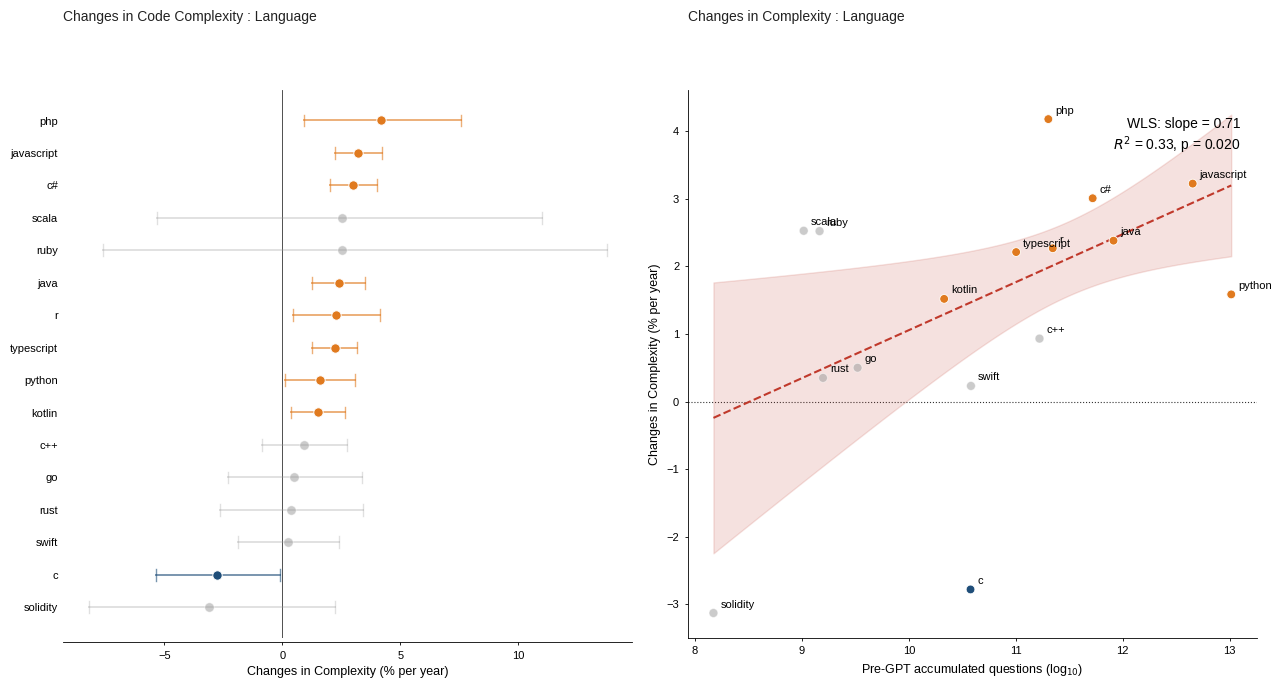

In [10]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

TARGET = 'log_cc_mean'   # 필요시 'log_y'(질문량)로 교체

# ============================================================
# 0. 데이터 준비
# ============================================================
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]

# ============================================================
# 1. 언어별 개별 회귀 (HAC)
# ============================================================
MIN_OBS = 30
formula_lang = f'{TARGET} ~ t + post + post_t'

rows = []
for lang in sorted(lang_df['language'].unique()):
    sub = lang_df[lang_df['language'] == lang].sort_values('t').copy()
    if len(sub) < MIN_OBS:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < {MIN_OBS}")
        continue
    try:
        m_lang = smf.ols(formula_lang, data=sub).fit(
            cov_type='HAC', cov_kwds={'maxlags': 4}
        )
    except Exception as e:
        print(f"[SKIP] {lang}: {e}")
        continue
    if m_lang.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue

    rows.append({
        "language": lang,
        "slope": m_lang.params["post_t"],
        "se":    m_lang.bse["post_t"],
        "n_obs": len(sub),
    })

slope_df = pd.DataFrame(rows)

# ============================================================
# 2. log-scale -> 연간(%) 변환
# ============================================================
WEEKS_PER_YEAR = 52
slope_df['slope_yr'] = slope_df['slope'] * WEEKS_PER_YEAR
slope_df['se_yr']    = slope_df['se']    * WEEKS_PER_YEAR

slope_df['pct']     = (np.exp(slope_df['slope_yr']) - 1) * 100
slope_df['ci_low']  = (np.exp(slope_df['slope_yr'] - 1.96*slope_df['se_yr']) - 1) * 100
slope_df['ci_high'] = (np.exp(slope_df['slope_yr'] + 1.96*slope_df['se_yr']) - 1) * 100

slope_df['p_value'] = 2 * (1 - stats.norm.cdf(np.abs(slope_df['slope_yr'] / slope_df['se_yr'])))
slope_df['significant'] = slope_df['p_value'] < 0.05

def get_color(row):
    if not row['significant']:
        return '#999999'
    elif row['pct'] > 0:
        return figure_setting.PALETTE['accent']
    else:
        return figure_setting.PALETTE['primary']

slope_df['color_slope'] = slope_df.apply(get_color, axis=1)
slope_df['alpha'] = np.where(slope_df['significant'], 1.0, 0.5)

# ============================================================
# 3. x축용 panel merge
# ============================================================
pre_data = panel.copy()
slope_df = pd.merge(slope_df, pre_data, on='language')

# ============================================================
# 4. WLS 추세선 (1차 SE^-2를 가중치로 사용)
# ============================================================
slope_df['weight'] = 1 / (slope_df['se_yr'] ** 2)

X = sm.add_constant(slope_df['log_post_count'])
wls_model = sm.WLS(slope_df['pct'], X, weights=slope_df['weight']).fit()

slope_fit     = wls_model.params['log_post_count']
intercept_fit = wls_model.params['const']
p_val         = wls_model.pvalues['log_post_count']
r_squared     = wls_model.rsquared

xx = np.linspace(slope_df['log_post_count'].min(), slope_df['log_post_count'].max(), 100)
X_pred = sm.add_constant(xx)
pred = wls_model.get_prediction(X_pred)
pred_summary = pred.summary_frame(alpha=0.05)   # mean_ci_lower / mean_ci_upper 포함

yy       = pred_summary['mean'].values
ci_low   = pred_summary['mean_ci_lower'].values
ci_high  = pred_summary['mean_ci_upper'].values

sorted_s = slope_df.sort_values('pct').reset_index(drop=True)

# ============================================================
# 5. 시각화 (왼쪽: 에러바, 오른쪽: WLS 산점도, 색상 통일)
# ============================================================
plotgen = PlotGen()
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 7))

# ---------- (A) 언어별 에러바 ----------
ax_a.axvline(0, color='#333', lw=0.6, zorder=1)

for i, row in sorted_s.iterrows():
    ax_a.plot([row['ci_low'], row['ci_high']], [i, i],
              color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_a.plot([xe, xe], [i-0.18, i+0.18],
                  color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    ax_a.scatter(row['pct'], i, s=46,
                 facecolor=row['color_slope'], edgecolor='white',
                 linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_a.set_yticks(np.arange(len(sorted_s)))
ax_a.set_yticklabels([f"{r['language']}" for _, r in sorted_s.iterrows()])
for s in ['top', 'right']:
    ax_a.spines[s].set_visible(False)
ax_a.spines['left'].set_visible(False)
ax_a.spines['bottom'].set_position(('outward', 3))
ax_a.tick_params(axis='y', length=0)
ax_a.set_xlabel('Changes in Complexity (% per year)')
plotgen.set_title_two_lines(ax_a, title_text='Changes in Code Complexity : Language')

# ---------- (B) WLS 산점도 (색상 통일) ----------
ax_b.axhline(0, color='#333', ls=':', lw=0.8, zorder=1)

ax_b.fill_between(xx, ci_low, ci_high,
                   color=figure_setting.PALETTE['event'], alpha=0.15, zorder=1)
ax_b.plot(xx, yy, color=figure_setting.PALETTE['event'], ls='--', lw=1.5, zorder=2)

ax_b.scatter(slope_df['log_post_count'], slope_df['pct'],
             s=40, facecolor=slope_df['color_slope'],
             edgecolor='white', linewidth=0.6, zorder=3,
             alpha=slope_df['alpha'])

for _, row in slope_df.iterrows():
    ax_b.annotate(row['language'], (row['log_post_count'], row['pct']),
                  textcoords="offset points", xytext=(5, 4), fontsize=8, zorder=4)

sig_str = 'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
ax_b.text(0.97, 0.95,
          f'WLS: slope = {slope_fit:.2f}\n$R^2$ = {r_squared:.2f}, {sig_str}',
          transform=ax_b.transAxes, ha='right', va='top', fontsize=10)

ax_b.set_xlabel('Pre-GPT accumulated questions (log$_{10}$)')
ax_b.set_ylabel('Changes in Complexity (% per year)')
for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
plotgen.set_title_two_lines(ax_b, title_text='Changes in Complexity : Language')

plt.tight_layout()
plt.savefig('./fig/Fig_individual_AB_wls.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
print(slope_df[['language', 'slope', 'slope_yr', 'pct']].sort_values('pct'))